# Project 1: Concept Bottleneck Models

Hugo Centeno Sanz - 100498982

Javier Calvo Artaso - 100498917

Agustín Dorado Sánchez - 100486151

Juan José Rosales Hernando - 100499176

In [1]:
!rm -rf celeba
!git clone https://github.com/centenohugo/CBMs celeba

Cloning into 'celeba'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 130 (delta 1), reused 2 (delta 0), pack-reused 122 (from 1)
Receiving objects: 100% (130/130), 172.16 MiB | 16.58 MiB/s, done.
Resolving deltas: 100% (54/54), done.
Updating files: 100% (20/20), done.


In [2]:
# Data handling
import os

# Numpy
import numpy as np

#Pytorch
import torch

# Data transformations and loading
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

# Pretrained models and weights
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


# Dataset and Preprocessing

In [3]:
# Define the local route in the colab SSD instance
path = "/content/celeba/resources/data"
os.makedirs(path, exist_ok=True)

# Download images
if not os.path.exists(f"{path}/img_align_celeba.zip"):
    print("Descargando imágenes (Mirror rápido)...")
    !wget -q --show-progress https://cseweb.ucsd.edu/~weijian/static/datasets/celeba/img_align_celeba.zip -O {path}/img_align_celeba.zip

# Metadata files already in the repo

print("Files ready in /content/celeba/resources/data (remote SSD)")

Descargando imágenes (Mirror rápido)...
/content/celeba/res 100%[===================>]   1.34G  58.2MB/s    in 21s     
Files ready in /content/celeba/resources/data (remote SSD)


In [4]:
# Move to the folder where the images are located
%cd /content/celeba/resources/data

# Unzip the file
!unzip -q img_align_celeba.zip

# Verify our structure is /content/celeba/resources/data/000001.jpg, etc.
if os.path.exists('/content/celeba/resources/data/img_align_celeba'):
    print("Expected structure found: /content/celeba/resources/data/img_align_celeba/")
else:
    print("Error: Expected structure not found.")

# Go back to the upper folder
%cd /content


/content/celeba/resources/data
Expected structure found: /content/celeba/resources/data/img_align_celeba/
/content


In [5]:
# Among the 40 feature CelebA has, we will focus on 10, and predict 'Smiling'
CONCEPT_NAMES = [
    'Mouth_Slightly_Open', 'High_Cheekbones', 'Chubby', 'Narrow_Eyes',
    'Bags_Under_Eyes', 'Big_Lips', 'Big_Nose', 'Pointy_Nose',
    'Bushy_Eyebrows', 'Arched_Eyebrows'
]
TARGET_NAME = 'Smiling'

In [6]:
# Go back to the folder where the images and the custom CelebA class are located for dataloader
%cd /content/celeba/resources/data
print("Current working directory:", os.getcwd())

#from celebacustom import CelebACustom
import inspect
from celebacustom import CelebACustom
print(inspect.signature(CelebACustom.__init__))


/content/celeba/resources/data
Current working directory: /content/celeba/resources/data
(self, root, concept_names, target_name, split='train', transform=None)


In [7]:
data_path = "/content/celeba/resources/data"
def get_dataloaders(root_dir=data_path, batch_size=64, num_workers=2):
    """
    Returns train, val, and test dataloaders for CelebA prepared for ResNet-18.
    """
    # Standard ImageNet normalization for ResNet-18
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
    ])

    # Download datasets
    train_ds = CelebACustom(root = root_dir, concept_names=CONCEPT_NAMES, target_name=TARGET_NAME, split='train', transform=transform)
    val_ds = CelebACustom(root = root_dir, concept_names=CONCEPT_NAMES, target_name=TARGET_NAME, split='valid', transform=transform)
    test_ds = CelebACustom(root = root_dir, concept_names=CONCEPT_NAMES, target_name=TARGET_NAME, split='test', transform=transform)

    # Load data into dataloaders
    trainloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    valloader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    testloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return trainloader, valloader, testloader

In [8]:
trainloader, valloader, testloader = get_dataloaders(root_dir=data_path, batch_size=64, num_workers=2)
train_dataset = trainloader.dataset
val_dataset = valloader.dataset
test_dataset = testloader.dataset

print("Train size:", len(train_dataset))
print("Valid size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 162770
Valid size: 19867
Test size: 19962


In [ ]:
# Check for the dimensions of the first sample on training dataset

img, concepts, target = train_dataset[0]
print("Image tensor shape:", img.shape)

# Check the concepts and target values
print("Concepts shape:", concepts.shape)
for name, val in zip(CONCEPT_NAMES, concepts):
    print(f"  {name}: {int(val.item())}")
print("Target (Smiling):", int(target.item()))


Image tensor shape: torch.Size([3, 224, 224])
Concepts shape: torch.Size([10])
  Mouth_Slightly_Open: 1
  High_Cheekbones: 1
  Chubby: 0
  Narrow_Eyes: 0
  Bags_Under_Eyes: 0
  Big_Lips: 0
  Big_Nose: 0
  Pointy_Nose: 1
  Bushy_Eyebrows: 0
  Arched_Eyebrows: 1
Target (Smiling): 1


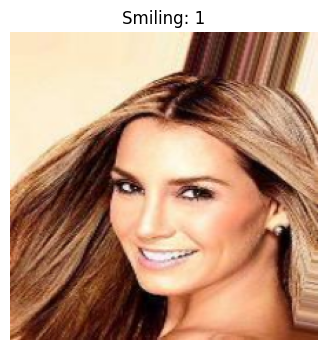

In [ ]:
# Visualizar imagen (desnormalizar primero)
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])
img_vis = img * std[:, None, None] + mean[:, None, None]
img_vis = img_vis.clamp(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_vis.permute(1, 2, 0))
plt.title(f"Smiling: {int(target.item())}")
plt.axis("off")
plt.show()

# Models

## Baseline Classifiers (x -> y)

In [ ]:
# Load the weights of the model to skip the training
%cd /content/celeba/models
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from backbone import Backbone
from baseline_classifier import BaselineClassifier_extended
backbone = Backbone()
my_baseline = BaselineClassifier_extended(backbone).to(device)

%cd ./weights
my_baseline.load_state_dict(torch.load('baseline_classifier.pth', map_location=device))

/content/celeba/models
/content/celeba/models/weights


<All keys matched successfully>

In [ ]:
#Skip this block if the model is already loaded
"""
# Hyperparams
lr = 1e-3
epochs = 1

%cd /content/celeba/models

from backbone import Backbone
from baseline_classifier import BaselineClassifier_extended

# Take advantage of cuda GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = Backbone()

my_baseline = BaselineClassifier_extended(backbone=backbone, epochs=epochs, lr=lr)
my_baseline = my_baseline.to(device)

my_baseline.trainloop(trainloader, valloader)
"""


'\n# Hyperparams\nlr = 1e-3\nepochs = 1\n\n%cd /content/celeba/models\n\nfrom backbone import Backbone\nfrom baseline_classifier import BaselineClassifier_extended\n\n# Take advantage of cuda GPUs\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nbackbone = Backbone()\n\nmy_baseline = BaselineClassifier_extended(backbone=backbone, epochs=epochs, lr=lr)\nmy_baseline = my_baseline.to(device)\n\nmy_baseline.trainloop(trainloader, valloader)\n'

In [ ]:
print(os.getcwd())
%cd /content/celeba/models/weights
torch.save(my_baseline.state_dict(), "baseline_classifier.pth")

/content/celeba/models/weights
/content/celeba/models/weights


In [ ]:
# Evaluation metrics: accuracy, AUROC, F1

import torch
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

my_baseline.eval()

all_y_true, all_y_pred, all_y_probs = [], [], []

with torch.no_grad():
    for x, _, y in testloader:
        x, y = x.to(device), y.to(device)

        logits = my_baseline(x)
        probs = torch.sigmoid(logits).squeeze(1)# As the model ends with nn.Linear
                                                # which returns a logit and we need
                                                # to match it with a probability
        preds = (probs > 0.5).float()

        all_y_true.append(y.cpu())
        all_y_pred.append(preds.cpu())
        all_y_probs.append(probs.cpu())

y_true = torch.cat(all_y_true).numpy()
y_pred = torch.cat(all_y_pred).numpy()
y_probs = torch.cat(all_y_probs).numpy()

print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Test AUROC:    {roc_auc_score(y_true, y_probs):.4f}")
print(f"Test F1:    {f1_score(y_true, y_pred):.4f}")


Test Accuracy: 0.9265
Test AUROC:    0.9819
Test F1:    0.9250


## Concept Predictor (x -> c)

First approach. A bit naive as we assume all concepts have the same frequency and their prediction is representative.

In [10]:
# Load the weights of the model to skip the training

device = 'cuda' if torch.cuda.is_available() else 'cpu'
%cd /content/celeba/models

from concept_predictor import ConceptPredictor_extended
from backbone import Backbone

backbone = Backbone()
my_concept_predictor = ConceptPredictor_extended(backbone=backbone).to(device)

%cd /content/celeba/models/weights
my_concept_predictor.load_state_dict(torch.load('concept_predictor.pth', map_location=device))

/content/celeba/models
/content/celeba/models/weights


<All keys matched successfully>

In [ ]:
# Skipt this block if the model is already loaded
"""
# Hyperparams
lr = 1e-3
epochs = 1

%cd /content/celeba/models

from backbone import Backbone
from concept_predictor import ConceptPredictor_extended

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = Backbone()

my_concept_predictor = ConceptPredictor_extended(backbone=backbone, num_concepts=10, epochs=epochs, lr=lr)
my_concept_predictor = my_concept_predictor.to(device)

my_concept_predictor.trainloop(trainloader, valloader)

print(os.getcwd())
%cd /content/celeba/models/weights
torch.save(my_concept_predictor.state_dict(), "concept_predictor.pth")
"""

'\n# Hyperparams\nlr = 1e-3\nepochs = 1\n\n%cd /content/celeba/models\n\nfrom backbone import Backbone\nfrom concept_predictor import ConceptPredictor_extended\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nbackbone = Backbone()\n\nmy_concept_predictor = ConceptPredictor_extended(backbone=backbone, num_concepts=10, epochs=epochs, lr=lr)\nmy_concept_predictor = my_concept_predictor.to(device)\n\nmy_concept_predictor.trainloop(trainloader, valloader)\n\nprint(os.getcwd())\n%cd /content/celeba/models/weights\ntorch.save(my_concept_predictor.state_dict(), "concept_predictor.pth")\n'

In [ ]:
#Evaluation per concept.

from sklearn.metrics import accuracy_score, f1_score
import numpy as np

my_concept_predictor.eval()

all_c_true, all_c_pred = [], []

with torch.no_grad():
    for x, c, _ in testloader:
        x = x.to(device)
        logits = my_concept_predictor(x)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_c_true.append(c.cpu())
        all_c_pred.append(preds.cpu())

c_true = torch.cat(all_c_true).numpy()   # shape (N, 10)
c_pred = torch.cat(all_c_pred).numpy()   # shape (N, 10)

print(f"{'Concept':<25} {'Accuracy':>10} {'F1':>10}")
print("-" * 47)
for i, name in enumerate(CONCEPT_NAMES):
    acc = accuracy_score(c_true[:, i], c_pred[:, i])
    f1  = f1_score(c_true[:, i], c_pred[:, i])
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")

print("-" * 47)
print(f"{'Macro Average':<25} {np.mean([accuracy_score(c_true[:,i], c_pred[:,i]) for i in range(10)]):>10.4f} "
      f"{f1_score(c_true, c_pred, average='macro'):>10.4f}")

Concept                     Accuracy         F1
-----------------------------------------------
Mouth_Slightly_Open           0.9347     0.9335
High_Cheekbones               0.8654     0.8485
Chubby                        0.9560     0.5168
Narrow_Eyes                   0.8745     0.3939
Bags_Under_Eyes               0.8528     0.5894
Big_Lips                      0.7055     0.2370
Big_Nose                      0.8389     0.5904
Pointy_Nose                   0.7669     0.3968
Bushy_Eyebrows                0.9056     0.6648
Arched_Eyebrows               0.7994     0.5011
-----------------------------------------------
Macro Average                 0.8500     0.5672


See how frequent are each of our concepts in our dateset to decide whether it makes sense to apply class weighting or not.

Disclaimer: we will decide based on our train set, assuming it is a representative data set.

In [ ]:
all_c = []
for _, c, _ in trainloader:
    all_c.append(c)

all_c = torch.cat(all_c, dim=0).numpy()  # shape (162770, 10)

print(f"{'Concept':<25} {'Positives':>10} {'Total':>10} {'% Positive':>12}")
print("-" * 60)
for i, name in enumerate(CONCEPT_NAMES):
    pos = all_c[:, i].sum()
    total = len(all_c)
    print(f"{name:<25} {int(pos):>10} {total:>10} {100*pos/total:>11.1f}%")

Concept                    Positives      Total   % Positive
------------------------------------------------------------
Mouth_Slightly_Open            78486     162770        48.2%
High_Cheekbones                73645     162770        45.2%
Chubby                          9389     162770         5.8%
Narrow_Eyes                    18869     162770        11.6%
Bags_Under_Eyes                33280     162770        20.4%
Big_Lips                       39213     162770        24.1%
Big_Nose                       38341     162770        23.6%
Pointy_Nose                    44846     162770        27.6%
Bushy_Eyebrows                 23386     162770        14.4%
Arched_Eyebrows                43278     162770        26.6%


Create positional weights to balance concepts. The more imbalanced are 'Chubby' 'Narrow Eyes' and 'Bushy Eyebrows'

In [ ]:
pos = all_c.sum(axis=0)
neg = len(all_c) - pos
pos_weight = neg / pos

# Parse it into a tensor and move it to the GPU memory
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

print(f"{'Concept':<25} {'pos_weight':>12}")
print("-" * 38)
for name, w in zip(CONCEPT_NAMES, pos_weight):
    print(f"{name:<25} {w:>12.2f}")

Concept                     pos_weight
--------------------------------------
Mouth_Slightly_Open               1.07
High_Cheekbones                   1.21
Chubby                           16.34
Narrow_Eyes                       7.63
Bags_Under_Eyes                   3.89
Big_Lips                          3.15
Big_Nose                          3.25
Pointy_Nose                       2.63
Bushy_Eyebrows                    5.96
Arched_Eyebrows                   2.76


Train new model which considers positional weights

In [ ]:
# Load the weights of the model to skip the training

device = 'cuda' if torch.cuda.is_available() else 'cpu'
%cd /content/celeba/models

from concept_predictor import ConceptPredictor_extended
from backbone import Backbone

backbone = Backbone()
my_concept_predictor_pos_weights = ConceptPredictor_extended(backbone=backbone,
                                                 num_concepts=10, epochs=epochs, lr=lr, pos_weight = pos_weight_tensor).to(device)

%cd /content/celeba/models/weights
my_concept_predictor_pos_weights.load_state_dict(torch.load('concept_predictor_pos_weights.pth', map_location=device))

/content/celeba/models
/content/celeba/models/weights


<All keys matched successfully>

In [ ]:
#Skip this block if model already loaded
"""
%cd /content/celeba/models

from backbone import Backbone
from concept_predictor import ConceptPredictor_extended

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = Backbone()

my_concept_predictor_pos_weights = ConceptPredictor_extended(backbone=backbone,
                                                 num_concepts=10, epochs=epochs, lr=lr, pos_weight = pos_weight_tensor)
my_concept_predictor_pos_weights = my_concept_predictor_pos_weights.to(device)

my_concept_predictor_pos_weights.trainloop(trainloader, valloader)

print(os.getcwd())
torch.save(my_concept_predictor_pos_weights.state_dict(), "concept_predictor_pos_weights.pth")
"""

'\n%cd /content/celeba/models\n\nfrom backbone import Backbone\nfrom concept_predictor import ConceptPredictor_extended\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nbackbone = Backbone()\n\nmy_concept_predictor_pos_weights = ConceptPredictor_extended(backbone=backbone,\n                                                 num_concepts=10, epochs=epochs, lr=lr, pos_weight = pos_weight_tensor)\nmy_concept_predictor_pos_weights = my_concept_predictor_pos_weights.to(device)\n\nmy_concept_predictor_pos_weights.trainloop(trainloader, valloader)\n\nprint(os.getcwd())\ntorch.save(my_concept_predictor_pos_weights.state_dict(), "concept_predictor_pos_weights.pth")\n'

In [ ]:
# Save results from model without pos_weight
c_true_no_w = c_true.copy()
c_pred_no_w = c_pred.copy()

In [ ]:
# Evaluate model with pos_weight
my_concept_predictor_pos_weights.eval()

all_c_true, all_c_pred = [], []

with torch.no_grad():
    for x, c, _ in testloader:
        x = x.to(device)
        logits = my_concept_predictor_pos_weights(x)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_c_true.append(c.cpu())
        all_c_pred.append(preds.cpu())

c_true_w = torch.cat(all_c_true).numpy()
c_pred_w = torch.cat(all_c_pred).numpy()

# Comparison table
print(f"{'Concept':<25} {'Acc (no w)':>12} {'F1 (no w)':>11} {'Acc (w)':>10} {'F1 (w)':>10}")
print("-" * 70)
for i, name in enumerate(CONCEPT_NAMES):
    acc_nw = accuracy_score(c_true_no_w[:, i], c_pred_no_w[:, i])
    f1_nw  = f1_score(c_true_no_w[:, i], c_pred_no_w[:, i])
    acc_w  = accuracy_score(c_true_w[:, i], c_pred_w[:, i])
    f1_w   = f1_score(c_true_w[:, i], c_pred_w[:, i])
    print(f"{name:<25} {acc_nw:>12.4f} {f1_nw:>11.4f} {acc_w:>10.4f} {f1_w:>10.4f}")

print("-" * 70)
print(f"{'Macro Average':<25}"
      f" {np.mean([accuracy_score(c_true_no_w[:,i], c_pred_no_w[:,i]) for i in range(10)]):>12.4f}"
      f" {f1_score(c_true_no_w, c_pred_no_w, average='macro'):>11.4f}"
      f" {np.mean([accuracy_score(c_true_w[:,i], c_pred_w[:,i]) for i in range(10)]):>10.4f}"
      f" {f1_score(c_true_w, c_pred_w, average='macro'):>10.4f}")

Concept                     Acc (no w)   F1 (no w)    Acc (w)     F1 (w)
----------------------------------------------------------------------
Mouth_Slightly_Open             0.9347      0.9335     0.9352     0.9335
High_Cheekbones                 0.8654      0.8485     0.8617     0.8582
Chubby                          0.9560      0.5168     0.8828     0.4391
Narrow_Eyes                     0.8745      0.3939     0.8383     0.5407
Bags_Under_Eyes                 0.8528      0.5894     0.8210     0.6395
Big_Lips                        0.7055      0.2370     0.6883     0.5793
Big_Nose                        0.8389      0.5904     0.7978     0.5937
Pointy_Nose                     0.7669      0.3968     0.7072     0.5958
Bushy_Eyebrows                  0.9056      0.6648     0.8108     0.5607
Arched_Eyebrows                 0.7994      0.5011     0.8121     0.7186
----------------------------------------------------------------------
Macro Average                   0.8500      0.5672     

As expected by weighting the concepts we improve F1 and reduce accuracy, as we force the model to detect more positives, reducing false negatives and increasing false positives.

In this case we could conclude weighting was of little help. We are now more prone to errors (our new accuracy is lower), but we detected better what were previously considered unbalanced or rare cases (e.g. a case were the concept chubby and narrow eyes are present)

## Bottleneck (x -> c -> y)

In [18]:
# Load the weights of the model to skip the training
%cd /content/celeba/models
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from backbone import Backbone
from concept_bottleneck_model import ConceptBottleneckModel

cbm_model = ConceptBottleneckModel()

cbm_model = cbm_model.to(device)

%cd ./weights
cbm_model.load_state_dict(torch.load('cbm_model.pth', map_location=device))

/content/celeba/models
/content/celeba/models/weights


<All keys matched successfully>

In [13]:
# Skip this block if model already loaded
"""
%cd /content/celeba/models
from concept_bottleneck_model import ConceptBottleneckModel, CBMTrainer

epochs = 1
lr = 1e-3

cbm_model = ConceptBottleneckModel()

cbm_model = cbm_model.to(device)

cbm_trainer = CBMTrainer(cbm_model, device, trainloader, valloader)

cbm_trainer.train(epochs=epochs, lr=lr)

torch.save(cbm_model.state_dict(), "cbm_model.pth")
"""

/content/celeba/models
Starting Joint Training: 1 epochs...
  Epoch [1/1] Batch [500/2544] Loss: 2.0977
  Epoch [1/1] Batch [1000/2544] Loss: 1.8659
  Epoch [1/1] Batch [1500/2544] Loss: 1.8573
  Epoch [1/1] Batch [2000/2544] Loss: 1.9213
  Epoch [1/1] Batch [2500/2544] Loss: 2.0039
Epoch [1/1] Completed. Average Loss: 2.0170



In [21]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

print("Evaluating model on the test set...")
cbm_model.eval() # Set model to evaluation mode

correct_y = 0
total_y = 0

all_y_true = []
all_y_probs = []
all_y_preds = [] # New list to collect binarized predictions

# We don't need gradients for testing, this saves memory and speeds it up
with torch.no_grad():
    # We use 'testloader' which your partner defined in the get_dataloaders function
    for images, true_concepts, true_labels in testloader:
        images = images.to(device)
        true_labels = true_labels.to(device).unsqueeze(1)

        # Forward pass
        concept_logits, y_logits = cbm_model(images)

        # Convert logits to probabilities (0.0 to 1.0)
        y_probs = torch.sigmoid(y_logits)

        # If probability > 0.5, predict 1 (Smiling), else predict 0
        y_preds = (y_probs > 0.5).float()

        # Calculate how many predictions match the true labels
        correct_y += (y_preds == true_labels).sum().item()
        total_y += true_labels.size(0)

        # Store for AUROC and F1 calculation
        all_y_true.extend(true_labels.cpu().numpy())
        all_y_probs.extend(y_probs.cpu().numpy())
        all_y_preds.extend(y_preds.cpu().numpy()) # Collect binarized predictions

# Calculate Test Accuracy
test_acc = correct_y / total_y

# Calculate Test AUROC (required by your project instructions!)
test_auroc = roc_auc_score(all_y_true, all_y_probs)

# Concatenate all predictions into a single numpy array for F1 score
final_y_preds = np.array(all_y_preds).flatten()

f1 = f1_score(all_y_true, final_y_preds) # Use collected y_preds for F1 calculation

print(f"====================================")
print(f"Test Accuracy for Smiling: {test_acc * 100:.2f}%")
print(f"Test AUROC for Smiling:    {test_auroc:.4f}")
print(f"Test F1 for Smiling:    {f1:.4f}")
print(f"====================================")

Evaluating model on the test set...
Test Accuracy for Smiling: 88.06%
Test AUROC for Smiling:    0.9672
Test F1 for Smiling:    0.8900


In [22]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

concept_names = [
    "Mouth_Slightly_Open", "High_Cheekbones", "Chubby", "Narrow_Eyes",
    "Bags_Under_Eyes", "Big_Lips", "Big_Nose", "Pointy_Nose",
    "Bushy_Eyebrows", "Arched_Eyebrows"
]

print("Evaluating concept predictions in the test set...")
cbm_model.eval()

all_c_true = []
all_c_preds = []

with torch.no_grad():
    for images, true_concepts, _ in testloader:
        images = images.to(device)

        # Forward pass: only focused on concepts
        concept_logits, _ = cbm_model(images)

        # Turn into probabilities via sigmoid function
        c_probs = torch.sigmoid(concept_logits)
        c_preds = (c_probs > 0.5).int()

        # Store the values
        all_c_true.append(true_concepts.cpu().numpy())
        all_c_preds.append(c_preds.cpu().numpy())

# Now we stack all batches
all_c_true = np.vstack(all_c_true)
all_c_preds = np.vstack(all_c_preds)

print("\n=== Concept Prediction Metrics ===")
f1_scores = []
accuracies = []

for i, name in enumerate(concept_names):
    # Now, we compute the accuracy and F1 for each concept
    acc = accuracy_score(all_c_true[:, i], all_c_preds[:, i])
    f1 = f1_score(all_c_true[:, i], all_c_preds[:, i], zero_division=0)

    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"{name:20s} -> Accuracy: {acc*100:.2f}% | F1 Score: {f1:.4f}")

print("--------------------------------------------------")
# "Mean concept performance (macro-average)"
print(f"Mean Concept Accuracy (Macro): {np.mean(accuracies)*100:.2f}%")
print(f"Mean Concept F1 Score (Macro): {np.mean(f1_scores):.4f}")
print("==================================================")

Evaluating concept predictions in the test set...

=== Concept Prediction Metrics ===
Mouth_Slightly_Open  -> Accuracy: 93.07% | F1 Score: 0.9273
High_Cheekbones      -> Accuracy: 83.88% | F1 Score: 0.8456
Chubby               -> Accuracy: 95.65% | F1 Score: 0.3944
Narrow_Eyes          -> Accuracy: 87.74% | F1 Score: 0.4115
Bags_Under_Eyes      -> Accuracy: 82.95% | F1 Score: 0.6442
Big_Lips             -> Accuracy: 70.23% | F1 Score: 0.2079
Big_Nose             -> Accuracy: 84.02% | F1 Score: 0.5894
Pointy_Nose          -> Accuracy: 75.18% | F1 Score: 0.5685
Bushy_Eyebrows       -> Accuracy: 92.22% | F1 Score: 0.6364
Arched_Eyebrows      -> Accuracy: 82.96% | F1 Score: 0.6515
--------------------------------------------------
Mean Concept Accuracy (Macro): 84.79%
Mean Concept F1 Score (Macro): 0.5877


## Hybrid CBM with side-channel (y = f(c) + s(x))

This model is a variation of the previous CBM model, but in this case a side-channel s(x) is added that predicts the target y directly from the image x. By summing the logits from both paths we will obtain the final prediction.

In [ ]:
# Load the weights of the model to skip the training

device = 'cuda' if torch.cuda.is_available() else 'cpu'
%cd /content/celeba/models

from hybrid_cbm import HybridCBM_extended
hybrid_model = HybridCBM_extended(cbm_model).to(device)

%cd /content/celeba/models/weights
%cd /content/celeba/models/weights/celeba/models/hybrid_cbm.py
hybrid_model.load_state_dict(torch.load('hybrid_model.pth', map_location=device))

/content/celeba/models
/content/celeba/models/weights
[Errno 2] No such file or directory: '/content/celeba/models/weights/celeba/models/hybrid_cbm.py'
/content/celeba/models/weights


<All keys matched successfully>

Skip training (next chunk) if you already have the weights.

In [ ]:
"""
from hybrid_cbm import HybridCBM_extended

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hybrid_model = HybridCBM_extended(cbm = cbm_model,
                                  dropout_p = 0.2,
                                  epochs = 1,
                                  lr = 0.001,
                                  lambda_c = 1.0)
hybrid_model = hybrid_model.to(device)
print("Model initialized successfully. Starting training...")
hybrid_model.trainloop(trainloader, valloader)
"""


'\nfrom hybrid_cbm import HybridCBM_extended\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nhybrid_model = HybridCBM_extended(cbm = cbm_model,\n                                  dropout_p = 0.2,\n                                  epochs = 1,\n                                  lr = 0.001,\n                                  lambda_c = 1.0)\nhybrid_model = hybrid_model.to(device)\nprint("Model initialized successfully. Starting training...")\nhybrid_model.trainloop(trainloader, valloader)\n'

In [ ]:
torch.save(hybrid_model.state_dict(), "hybrid_model.pth")

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score # Added f1_score import

print(f"\n--- Testing Hybrid model with p = 0.3 ---")

# Evaluation on test set (both concepts and target)
hybrid_model.eval()
y_true, y_probs = [], []
c_true, c_preds = [], []

with torch.no_grad():
    for x, c, y in testloader:
        x = x.to(device)
        c_logits, y_logits = hybrid_model(x)

        y_true.extend(y.cpu().numpy())
        y_probs.extend(torch.sigmoid(y_logits).cpu().numpy())

        c_true.append(c.cpu().numpy())
        c_preds.append((torch.sigmoid(c_logits) > 0.5).int().cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs).flatten()
y_preds = (y_probs > 0.5).astype(float)

acc = accuracy_score(y_true, y_preds)
auroc = roc_auc_score(y_true, y_probs)
f1 = f1_score(y_true, y_preds) # Added F1 calculation

c_true_all = np.vstack(c_true)
c_pred_all = np.vstack(c_preds)
mean_c_acc = np.mean([accuracy_score(c_true_all[:, i], c_pred_all[:, i]) for i in range(10)])

# Updated print statement to include F1
print(f"Results for p=0.3: Acc={acc:.4f}, AUROC={auroc:.4f}, F1={f1:.4f}, Concept Acc={mean_c_acc:.4f}")


--- Testing Hybrid model with p = 0.3 ---
Results for p=0.3: Acc=0.9303, AUROC=0.9830, F1=0.9307, Concept Acc=0.8551


We will now compare the model's performace for different dropout probabilities:

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from hybrid_cbm import HybridCBM_extended

dropout_values = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for p in dropout_values:
    print(f"\n--- Testing Dropout p={p} ---")
    # New hybrid model with current dropout
    model = HybridCBM_extended(cbm=cbm_model, dropout_p=p, epochs=epochs, lr=lr)
    model = model.to(device)

    # Train
    model.trainloop(trainloader, valloader)

    # Evaluation on test set (both concepts and target)
    model.eval()
    y_true, y_probs = [], []
    c_true, c_preds = [], []

    with torch.no_grad():
        for x, c, y in testloader:
            x = x.to(device)
            c_logits, y_logits = model(x)

            y_true.extend(y.cpu().numpy())
            y_probs.extend(torch.sigmoid(y_logits).cpu().numpy())

            c_true.append(c.cpu().numpy())
            c_preds.append((torch.sigmoid(c_logits) > 0.5).int().cpu().numpy())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs).flatten()
    y_preds = (y_probs > 0.5).astype(float)

    acc = accuracy_score(y_true, y_preds)
    auroc = roc_auc_score(y_true, y_probs)

    c_true_all = np.vstack(c_true)
    c_pred_all = np.vstack(c_preds)
    mean_c_acc = np.mean([accuracy_score(c_true_all[:, i], c_pred_all[:, i]) for i in range(10)])

    results.append({
        'p': p,
        'acc': acc,
        'auroc': auroc,
        'c_acc': mean_c_acc
    })
    print(f"Results for p={p}: Acc={acc:.4f}, AUROC={auroc:.4f}, Concept Acc={mean_c_acc:.4f}")


--- Testing Dropout p=0.0 ---
Starting training: 1 epochs, lr=0.001, 2544 train batches, 311 val batches, device=cuda:0


Epoch 1/1 — training...
  Epoch 1/1  batch 100/2544  Total Loss: 0.4735 (Task: 0.1954, Concept: 0.2780)
  Epoch 1/1  batch 200/2544  Total Loss: 0.3968 (Task: 0.1102, Concept: 0.2866)
  Epoch 1/1  batch 300/2544  Total Loss: 0.4200 (Task: 0.1598, Concept: 0.2602)
  Epoch 1/1  batch 400/2544  Total Loss: 0.5149 (Task: 0.1940, Concept: 0.3209)
  Epoch 1/1  batch 500/2544  Total Loss: 0.4553 (Task: 0.1676, Concept: 0.2877)
  Epoch 1/1  batch 600/2544  Total Loss: 0.3467 (Task: 0.0908, Concept: 0.2558)
  Epoch 1/1  batch 700/2544  Total Loss: 0.4186 (Task: 0.0928, Concept: 0.3258)
  Epoch 1/1  batch 800/2544  Total Loss: 0.3848 (Task: 0.1133, Concept: 0.2715)
  Epoch 1/1  batch 900/2544  Total Loss: 0.4116 (Task: 0.1525, Concept: 0.2591)
  Epoch 1/1  batch 1000/2544  Total Loss: 0.5319 (Task: 0.2598, Concept: 0.2721)
  Epoch 1/1  batch 1100/2544  Total Loss: 0.4129 (Ta

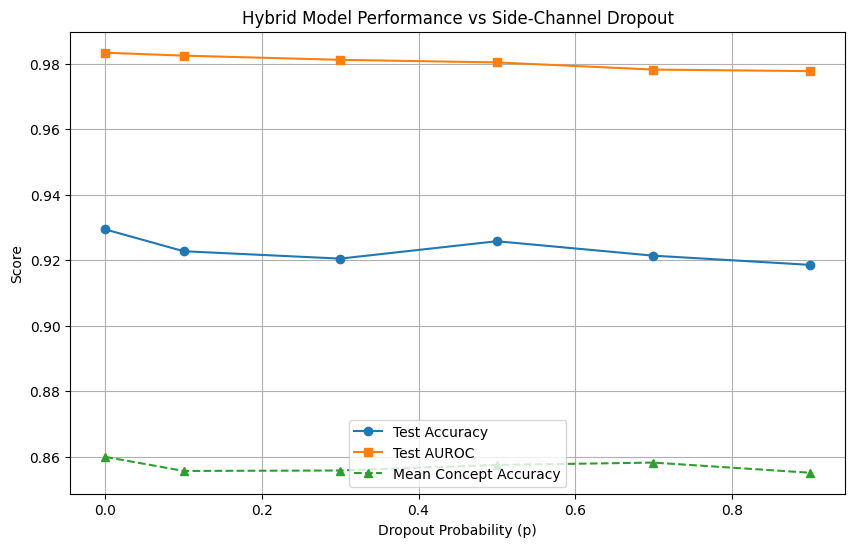

In [ ]:
ps = [r['p'] for r in results]
accs = [r['acc'] for r in results]
arocs = [r['auroc'] for r in results]
c_accs = [r['c_acc'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(ps, accs, marker='o', label='Test Accuracy')
plt.plot(ps, arocs, marker='s', label='Test AUROC')
plt.plot(ps, c_accs, marker='^', label='Mean Concept Accuracy', linestyle='--')

plt.xlabel('Dropout Probability (p)')
plt.ylabel('Score')
plt.title('Hybrid Model Performance vs Side-Channel Dropout')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Results

1. **Side-Channel vs. Bottleneck**: As dropout $p$ increases, the side-channel $s(x)$ loses importance (more chances of dropping the channel). This increases the importance of the concept bottleneck $f(c)$ path.
2. **Accuracy Trends**: the Accuracy and AUROC stays high even at high dropout, which suggests that our concept bottleneck path is robust.
3. **Concept Accuracy**: The mean concept accuracy is also stable even for high values of $p$, remaining above 0.85 across all tested probabilities. This ensures the strong performance of the CBM target prediction.

# Steerability and Concept Interventions


We evaluate how controllable each model is through concept-level interventions.

**Procedure:** For each test image, we:
1. Compute the predicted concept vector (binarized)
2. Flip one concept at a time (0→1 or 1→0), keeping the rest fixed
3. Rerun the label prediction head `c → y`
4. Measure:
   - **Avg. probability change**: mean |p_new - p_base| across all samples
   - **Flip rate**: fraction of samples where the predicted label changes

Concepts are ranked by average probability change.


In [ ]:
%cd /content/celeba
from steerablity import evaluate_steerability, print_steerability_ranking, CONCEPT_NAMES

print("=== CBM ===")
cbm_model.c_to_y = cbm_model.label_head
ranking_cbm = evaluate_steerability(cbm_model, testloader, device)
print_steerability_ranking(ranking_cbm)

/content/celeba
=== CBM ===


Intervening: 100%|██████████| 312/312 [00:52<00:00,  5.93it/s]

--- STEERABILITY AND CONCEPT INTERVENTION RANKING ---
1. High_Cheekbones
   Avg. change in predicted label probability: 0.3774
   Fraction of samples with changed label:     55.01%

2. Big_Lips
   Avg. change in predicted label probability: 0.3545
   Fraction of samples with changed label:     34.92%

3. Mouth_Slightly_Open
   Avg. change in predicted label probability: 0.2611
   Fraction of samples with changed label:     55.12%

4. Big_Nose
   Avg. change in predicted label probability: 0.1073
   Fraction of samples with changed label:     5.66%

5. Bushy_Eyebrows
   Avg. change in predicted label probability: 0.0940
   Fraction of samples with changed label:     15.87%

6. Chubby
   Avg. change in predicted label probability: 0.0626
   Fraction of samples with changed label:     2.78%

7. Pointy_Nose
   Avg. change in predicted label probability: 0.0621
   Fraction of samples with changed label:     4.00%

8. Arched_Eyebrows
   Avg. change in predicted label probability: 0.0591
   F

In [ ]:
print("=== Hybrid CBM ===")
hybrid_model.c_to_y = hybrid_model.cbm.label_head
hybrid_model.side_channel = hybrid_model.side_head
hybrid_model.concept_predictor = hybrid_model.cbm
ranking_hybrid = evaluate_steerability(hybrid_model, testloader, device)
print_steerability_ranking(ranking_hybrid)

=== Hybrid CBM ===


Intervening: 100%|██████████| 312/312 [00:56<00:00,  5.53it/s]


--- STEERABILITY AND CONCEPT INTERVENTION RANKING ---
1. High_Cheekbones
   Avg. change in predicted label probability: 0.1666
   Fraction of samples with changed label:     16.86%

2. Big_Lips
   Avg. change in predicted label probability: 0.1226
   Fraction of samples with changed label:     10.59%

3. Mouth_Slightly_Open
   Avg. change in predicted label probability: 0.0963
   Fraction of samples with changed label:     7.16%

4. Big_Nose
   Avg. change in predicted label probability: 0.0390
   Fraction of samples with changed label:     2.77%

5. Bushy_Eyebrows
   Avg. change in predicted label probability: 0.0322
   Fraction of samples with changed label:     2.38%

6. Chubby
   Avg. change in predicted label probability: 0.0226
   Fraction of samples with changed label:     1.61%

7. Pointy_Nose
   Avg. change in predicted label probability: 0.0223
   Fraction of samples with changed label:     1.49%

8. Arched_Eyebrows
   Avg. change in predicted label probability: 0.0211
   Fra

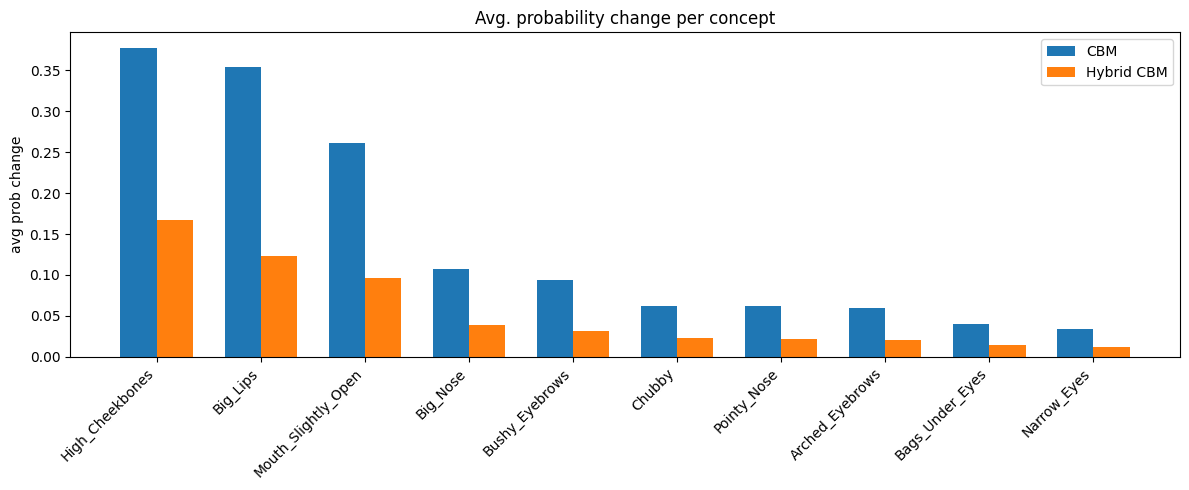

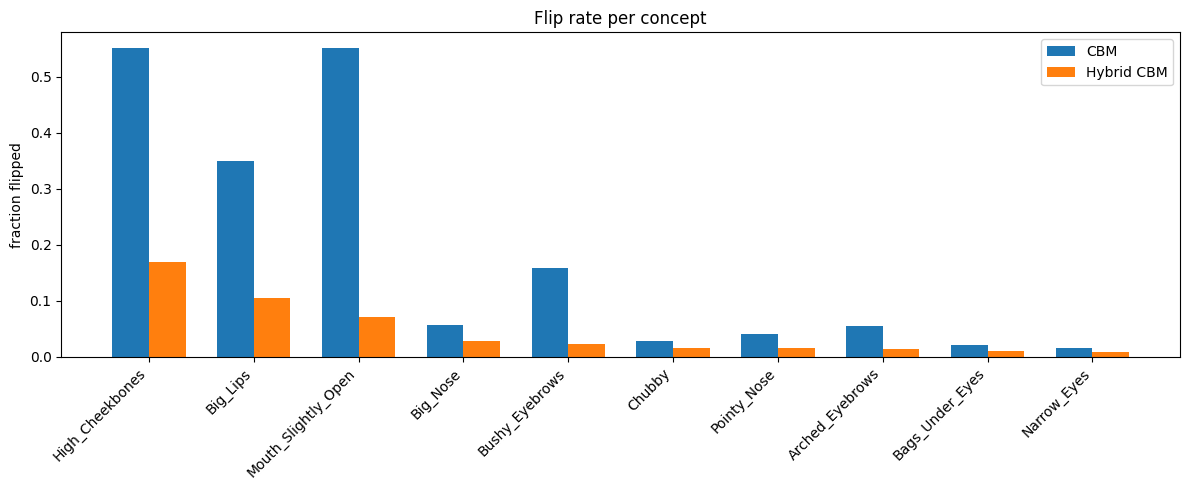

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_steerability(ranking_cbm, ranking_hybrid, metric='avg_prob_change'):
    # Aline in the same concept order
    names = [r['concept_name'] for r in ranking_cbm]  # CBM order
    hybrid_map = {r['concept_name']: r[metric] for r in ranking_hybrid}

    vals_cbm    = [r[metric] for r in ranking_cbm]
    vals_hybrid = [hybrid_map[n] for n in names]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, vals_cbm,    width, label='CBM')
    ax.bar(x + width/2, vals_hybrid, width, label='Hybrid CBM')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    title = 'Avg. probability change per concept' if metric == 'avg_prob_change' else 'Flip rate per concept'
    ax.set_title(title)
    ax.set_ylabel(metric.replace('_', ' '))
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_steerability(ranking_cbm, ranking_hybrid, metric='avg_prob_change')
plot_steerability(ranking_cbm, ranking_hybrid, metric='fraction_flipped')

### Interpretation of Results

The ranking is consistent across both models: **High_Cheekbones**, **Mouth_Slightly_Open** and **Pointy_Nose** are the most influential concepts, while **Big_Lips** and **Big_Nose** have almost no effect on the final prediction. The first two make intuitive sense as smiling physically raises the cheeks and opens the mouth. Pointy_Nose ranking this high suggests a spurious correlation learned from the dataset.

The Hybrid CBM is 3-4x less steerable than the standard CBM across all concepts. This is expected: the side-channel s(x) absorbs part of the predictive signal, partially compensating for concept interventions and reducing their effect. This confirms the interpretability trade-off of the Hybrid architecture — the accuracy gains from s(x) come at the cost of reduced controllability.

# Attacks

As an introduction to project 2, we'll perform a FGSM attack on our models to see how robust our model is. Adversarial training will be left for project 2.

## FGSM attack on the baseline classifier

In [ ]:
# Preparation of functions needed for the attack

# After perturbing the image clips values which have gone outside limitss [0, 1]
def clamp_normalized(x):
    # For each channel (transformations applied to fit ResNet-18), valid min = (0 - mean) / std, valid max = (1 - mean) / std
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(x.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(x.device)
    low = (0 - mean) / std
    high = (1 - mean) / std
    return torch.clamp(x, min=low, max=high)

# Evaluate without tracking gradients. No needed in evaluation. We save memory.
@torch.no_grad()
def predict(model, x):
    model.eval()
    logits = model(x)
    # Binary classification. Sigmoid threshold of 0.5 in probability space corresponds to a logit of 0.
    return (logits.squeeze() > 0).long()

# Visualize altered batch
def show_batch(images, labels=None, preds=None, n=8, title=None):
    images = images.detach().cpu()
    # Undo ResNet-18 normalization for image display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images = images * std + mean
    images = images.clamp(0, 1)

    n = min(n, images.size(0))
    fig, axes = plt.subplots(1, n, figsize=(1.8*n, 2.0))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(images[i].permute(1, 2, 0)) # (C,H,W) -> (H,W,C)
                                                    # Pytorch channel storing storing -> Matplotlib channel storing
        axes[i].axis("off")
        t = []
        if labels is not None: t.append(f"y={int(labels[i])}")
        if preds is not None:  t.append(f"p={int(preds[i])}")
        axes[i].set_title("\n".join(t), fontsize=10)
    if title:
        fig.suptitle(title)
    plt.show()

# Obtaing a metric of how much the adversarial image differs from the OG
def l_inf_norm(x_adv, x):
    # per-sample L_inf norm
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values


In [ ]:
import torch.nn.functional as F # Contains the functional version of the loss used

def fgsm_attack_baseline(model, x, y, eps):
    """
    Untargeted FGSM: maximize loss wrt true label y.
    As our baseline model performs binary classification targeted and untargeted
    conceptually are the same attack.
    """
    model.eval()
    # Make copy of the OG images, disconnect from previous computation graph
    # and trajc gradients with respect to this tensor (x_adv)
    # we do not compute gradients with respect to model weights,
    # but with respect to the input image.
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)

    # loss between model's prediction and true label.
    loss = F.binary_cross_entropy_with_logits(logits.squeeze(), y.float())
    # untargeted: gradient *ascent* on loss => add sign(grad)
    # track direction that increases the loss for each pixel
    grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
    # Step in the direction that increases the loss. I.e. push the
    # input away from being correctly classified
    x_adv = x_adv + eps * grad_sign

    x_adv = clamp_normalized(x_adv.detach())
    return x_adv


Clean acc on this batch: 0.9375
FGSM  acc on this batch: 0.109375
Max L_inf in batch: 0.15000009536743164


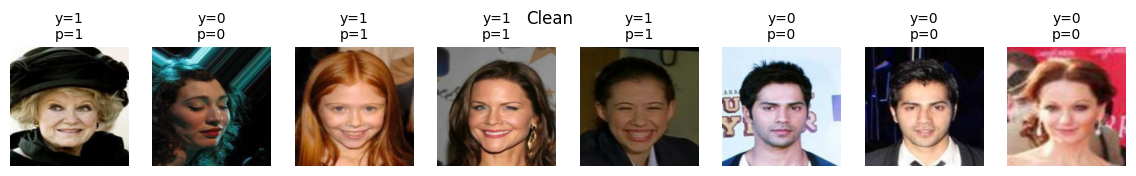

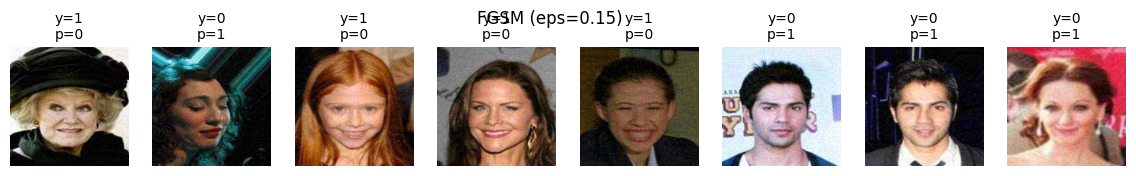

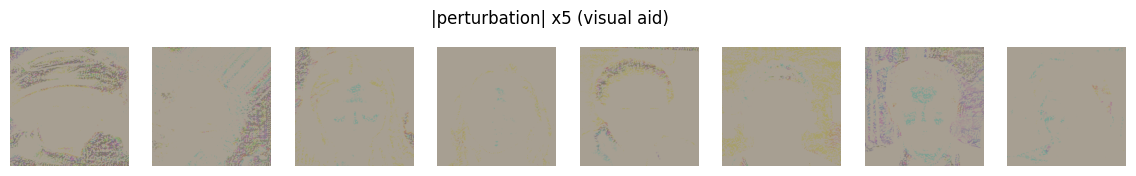

In [ ]:
x, _, y = next(iter(testloader)) # Out dataset contains concepts which do not care about
                                  # for this model
x, y = x.to(device), y.to(device)

with torch.no_grad():
    p_clean = predict(my_baseline, x)

eps = 0.15
x_fgsm = fgsm_attack_baseline(my_baseline, x, y, eps=eps)

with torch.no_grad():
    p_adv = predict(my_baseline, x_fgsm)

print("Clean acc on this batch:", (p_clean == y).float().mean().item())
print("FGSM  acc on this batch:", (p_adv == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_fgsm, x).max().item())

show_batch(x[:8], labels=y[:8], preds=p_clean[:8], title="Clean")
show_batch(x_fgsm[:8], labels=y[:8], preds=p_adv[:8], title=f"FGSM (eps={eps})")
show_batch((x_fgsm - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


Pretty impresive results, we have moved the model from 89% acc. to 9% acc. with unnoticeable perturbations.

## FGSM attack on the concept predictor

As when predicting concepts we are predicting multiple classes, we can perform targeted attacks.
We'll attack one of the less usual concepts, as it was 'Chubby' to see what happens and how this concept may be related to others.

In [ ]:
import torch.nn.functional as F # Contains the functional version of the loss used

@torch.no_grad()
def predict_concepts(model, x):
    model.eval()
    logits = model(x)
    # Each of the 10 concepts is thresholded independently
    return (logits > 0).long()

def fgsm_attack_single_concept(model, x, c, eps, concept_idx):
    """
    Targeted FGSM: flip a single concept prediction.
    Maximizes loss on one specific concept only.
    """
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)  # shape: (batch_size, 10)

    # Loss on only the targeted concept
    loss = F.binary_cross_entropy_with_logits(
        logits[:, concept_idx], c[:, concept_idx].float()
    )
    grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
    x_adv = x_adv + eps * grad_sign

    x_adv = clamp_normalized(x_adv.detach())
    return x_adv

Attacking concept: Chubby
Target concept 'Chubby' flip rate: 0.922



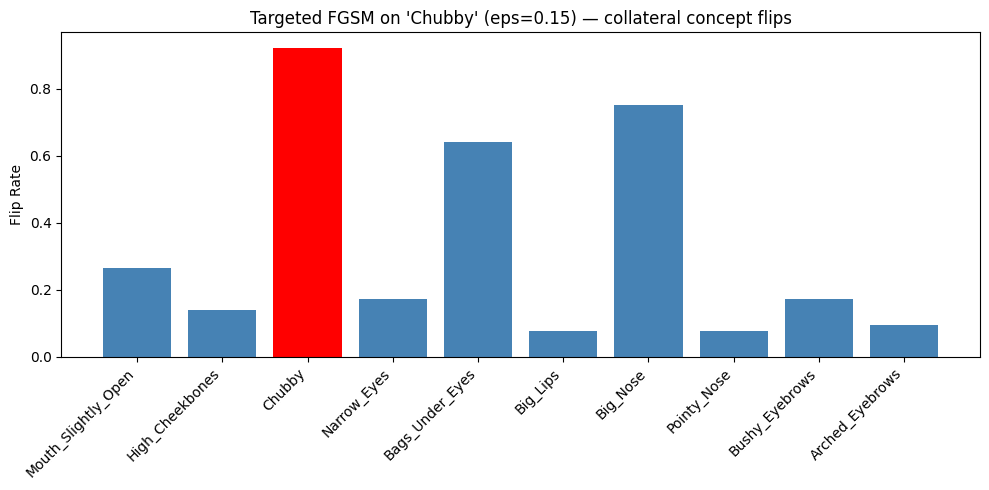

In [ ]:
concept_names = CONCEPT_NAMES

# Attack "Chubby" (index 2)
target_concept = 2
target_name = concept_names[target_concept]
print("Attacking concept:", target_name)

x, c, _ = next(iter(testloader))
x, c = x.to(device), c.to(device)

c_clean = predict_concepts(my_concept_predictor, x)

eps = 0.15
x_adv = fgsm_attack_single_concept(my_concept_predictor, x, c, eps, concept_idx=target_concept)

c_adv = predict_concepts(my_concept_predictor, x_adv)

# See how sucessful is the attack
target_flip_rate = (c_clean[:, target_concept] != c_adv[:, target_concept]).float().mean().item()
print(f"Target concept '{target_name}' flip rate: {target_flip_rate:.3f}\n")

# Visualize what percentange of the other concepts are flipped when Chubby is
import matplotlib.pyplot as plt

flip_rates = [(c_clean[:, i] != c_adv[:, i]).float().mean().item() for i in range(10)]
colors = ['red' if i == target_concept else 'steelblue' for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(concept_names, flip_rates, color=colors)
ax.set_ylabel("Flip Rate")
ax.set_title(f"Targeted FGSM on '{target_name}' (eps={eps}) — collateral concept flips")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As expected, all the concepts suffer from collateral damages caused by flipping Chubby, but it is pretty interesting to see how the concepts which affect the most are  'Big Nose' and 'Bags Under Eyes'. We could infer a correlation between these features.